In [1]:
import numpy as np
import pandas as pd

import re
import ast

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ===== Config =====

DATA_DIR = Path("/Users/nithinprince/Downloads/student_pack-2/data")     # put train.csv and test.csv here, or change this folder
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH  = DATA_DIR / "test.csv"

EMB_PATH = DATA_DIR / "airbnb-use-embeddings.csv"  # optional

SEED = 26
VALID_FRAC = 0.20
RIDGE_ALPHA = 50.0

# Embeddings: 'none' | 'sample' | 'svd'
EMBEDDING_MODE = "none"
EMBEDDING_SAMPLE_K = 200
EMBEDDING_SVD_K = 200

In [3]:
# ===== Load =====

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Missing: {TRAIN_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"Missing: {TEST_PATH}")

train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
test_df  = pd.read_csv(TEST_PATH,  low_memory=False)

print("train shape", train_df.shape)
print("test shape ", test_df.shape)

train_df.head()

train shape (23314, 94)
test shape  (5828, 93)


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,requires_license,license,jurisdiction_names,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,10647977,https://www.airbnb.com/rooms/10647977,20180303203649,2018-03-04,Cozy studio in WaHi,n,NaN,n,none,NaN,...,f,NaN,NaN,f,f,moderate,f,f,1,0.90
1,16193729,https://www.airbnb.com/rooms/16193729,20180303203649,2018-03-05,Shining room D /3min to Subway,I have other listings in the same apartment: h...,We are sharing a four bedroom apartment at sun...,I have other listings in the same apartment: h...,none,The Apt is between the 4th and 5th AV. The 5th...,...,f,NaN,NaN,f,f,moderate,f,f,8,0.86
2,7784365,https://www.airbnb.com/rooms/7784365,20180303203649,2018-03-04,Great cozy room 5 minutes to city,Private room in 2BR Apart. A short walk away ...,Situated in the up-in-coming neighborhood of L...,Private room in 2BR Apart. A short walk away ...,none,"near subway..near restaurants, safe area",...,f,NaN,NaN,f,f,flexible,f,f,2,0.57
3,2101200,https://www.airbnb.com/rooms/2101200,20180303203649,2018-03-04,"Steps from Central Park, West 80s","Close to Central Park. Converted 2 bedroom, tr...",It is very close to Central Park and steps fro...,"Close to Central Park. Converted 2 bedroom, tr...",none,A quiet tree lined street on the Upper West si...,...,f,NaN,NaN,f,f,flexible,f,f,1,1.18
4,20620313,https://www.airbnb.com/rooms/20620313,20180303203649,2018-03-05,Modern Luxury 2 Bedroom w/ Private Deck!,Explore Brooklyn and NYC from this modern luxu...,NaN,Explore Brooklyn and NYC from this modern luxu...,none,NaN,...,f,NaN,NaN,f,f,moderate,f,f,1,0.46


In [4]:
# ===== Helpers =====

def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0.0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


def parse_money_to_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    s = str(x).strip()
    if not s or s.lower() in {"na", "nan", "none", "null"}:
        return np.nan

    # handle percent strings like "90%" -> 0.9 (kept for robustness)
    if s.endswith("%"):
        try:
            return float(s[:-1]) / 100.0
        except Exception:
            return np.nan

    # handle parentheses for negatives "(50)" -> -50
    neg = False
    if s.startswith("(") and s.endswith(")"):
        neg = True
        s = s[1:-1].strip()

    s = re.sub(r"[\$,]", "", s)  # remove $ and commas

    try:
        val = float(s)
        return -val if neg else val
    except Exception:
        return np.nan


def parse_percent_to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if not s:
        return np.nan
    if s.endswith("%"):
        s = s[:-1]
    try:
        return float(s) / 100.0
    except Exception:
        return np.nan


def to_bool01(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, bool):
        return 1.0 if x else 0.0
    s = str(x).strip().lower()
    if s in {"t", "true", "1", "yes", "y"}:
        return 1.0
    if s in {"f", "false", "0", "no", "n"}:
        return 0.0
    return np.nan


def parse_listlike(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(i).strip() for i in x if str(i).strip()]

    s = str(x).strip()
    if not s or s.lower() in {"na", "nan", "none", "null", "[]"}:
        return []

    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(i).strip() for i in v if str(i).strip()]
    except Exception:
        pass

    s2 = s.strip("[]").replace("'", "").replace('"', "")
    parts = [p.strip() for p in s2.split(",") if p.strip()]
    return parts


def clean_zipcode(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = s.split("-")[0].split("\\")[0].strip()
    s = re.sub(r"\s+", "", s)
    return s[:5] if re.match(r"^\d{5}", s) else np.nan


def safe_days_since(date_series, ref_date):
    d = pd.to_datetime(date_series, errors="coerce")
    return (ref_date - d).dt.days


def freq_encode_from_train(train_s, test_s):
    tr = train_s.fillna("NaN").astype(str)
    te = test_s.fillna("NaN").astype(str)
    freq = tr.value_counts(normalize=True)
    return (
        tr.map(freq).fillna(0).to_numpy().reshape(-1, 1),
        te.map(freq).fillna(0).to_numpy().reshape(-1, 1),
    )


def fit_ridge(X: np.ndarray, y: np.ndarray, alpha: float) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    n = X.shape[0]

    X1 = np.hstack([np.ones((n, 1)), X])
    d = X1.shape[1]

    I = np.eye(d)
    I[0, 0] = 0.0

    A = X1.T @ X1 + alpha * I
    b = X1.T @ y
    w = np.linalg.solve(A, b)
    return w


def predict_ridge(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    X1 = np.hstack([np.ones((n, 1)), X])
    return X1 @ w


def standardize_fit(X: np.ndarray):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0
    return mean, std


def standardize_apply(X: np.ndarray, mean: np.ndarray, std: np.ndarray):
    return (X - mean) / std

In [5]:
print(f"train shape {train_df.shape}")
print(f"test shape  {test_df.shape}")

missing = train_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nMissing (train, >0 only):")
print(missing.head(30))

train shape (23314, 94)
test shape  (5828, 93)

Missing (train, >0 only):
license                  23314
thumbnail_url            23314
medium_url               23314
xl_picture_url           23314
host_acceptance_rate     23314
jurisdiction_names       23313
square_feet              23041
notes                    13256
security_deposit          9488
interaction               8711
access                    8228
neighborhood_overview     8035
host_about                7981
house_rules               7930
transit                   7199
host_response_rate        6365
host_response_time        6365
space                     5836
cleaning_fee              4550
host_neighbourhood        3007
summary                    711
zipcode                    288
market                      67
host_location               66
city                        25
beds                        15
description                 10
neighbourhood                7
name                         4
state                      

In [6]:
#Preprocess


SCRAPE_DATE = pd.to_datetime(train_df.get("last_scraped"), errors="coerce").max()
if pd.isna(SCRAPE_DATE):
    SCRAPE_DATE = pd.Timestamp("2017-01-01")

# Clean zipcode
if "zipcode" in train_df.columns:
    train_df["zipcode"] = train_df["zipcode"].apply(clean_zipcode)
if "zipcode" in test_df.columns:
    test_df["zipcode"] = test_df["zipcode"].apply(clean_zipcode)

# Percent fields
for c in ["host_response_rate", "host_acceptance_rate"]:
    if c in train_df.columns:
        train_df[c] = train_df[c].apply(parse_percent_to_float)
    if c in test_df.columns:
        test_df[c] = test_df[c].apply(parse_percent_to_float)

# Cap sentinel values
for df in [train_df, test_df]:
    if "maximum_nights" in df.columns:
        df["maximum_nights"] = pd.to_numeric(df["maximum_nights"], errors="coerce").clip(upper=1125)

# Date derived features
for df in [train_df, test_df]:
    if "host_since" in df.columns:
        df["host_tenure_days"] = safe_days_since(df["host_since"], SCRAPE_DATE).clip(lower=0)
    if "first_review" in df.columns:
        df["days_since_first_review"] = safe_days_since(df["first_review"], SCRAPE_DATE).clip(lower=0)
        df["has_reviews"] = pd.to_datetime(df["first_review"], errors="coerce").notna().astype(float)
    if "last_review" in df.columns:
        df["days_since_last_review"] = safe_days_since(df["last_review"], SCRAPE_DATE).clip(lower=0)

# remove zero price rows (train only)
if "price" in train_df.columns:
    train_df = train_df[train_df["price"].astype(float) > 0].reset_index(drop=True)

print("After preprocess -> train shape", train_df.shape)
print("After preprocess -> test shape ", test_df.shape)

After preprocess -> train shape (23291, 98)
After preprocess -> test shape  (5828, 97)


### Preprocessing

The preprocessing step cleans and standardizes key features such as zipcodes and percentage fields, and caps extreme values in maximum_nights. It also creates time based features like host_tenure_days and review related features from date columns. Finally, listings with zero prices were removed from the training data to avoid invalid targets.

In [7]:
# ===== Column groups =====

PRICE_COLUMNS = ["price", "weekly_price", "monthly_price"]

NUMERIC_COLS = [
    "host_listings_count",
    "host_total_listings_count",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "guests_included",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    # added date-derived numeric features if present:
    "host_tenure_days",
    "days_since_first_review",
    "days_since_last_review",
    "has_reviews",
    # percent fields if present:
    "host_response_rate",
    "host_acceptance_rate",
]

# include extra_people as money-like
STRING_NUMERIC_COLS = ["beds", "security_deposit", "cleaning_fee", "extra_people"]

BOOL_COLS = [
    "require_guest_profile_picture",
    "require_guest_phone_verification",
    "instant_bookable",
    "is_business_travel_ready",
    "has_availability",
    "is_location_exact",
    "host_identity_verified",
    "host_has_profile_pic",
    "host_is_superhost",
]

CAT_COLS = [
    "property_type",
    "room_type",
    "bed_type",
    "cancellation_policy",
    "host_response_time",
]

SET_COL = "host_verifications"

LOC_COLS = ["latitude", "longitude"]
ZIP_COL = "zipcode"

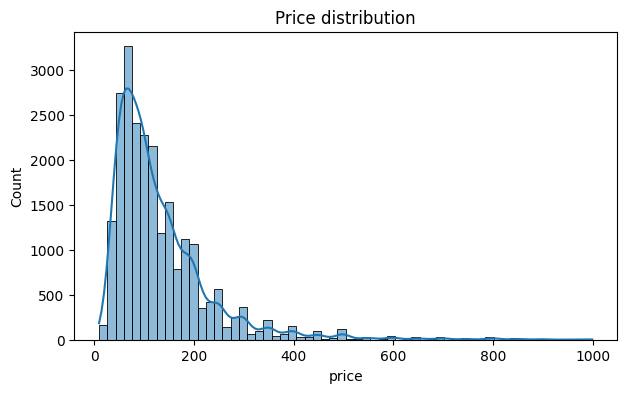

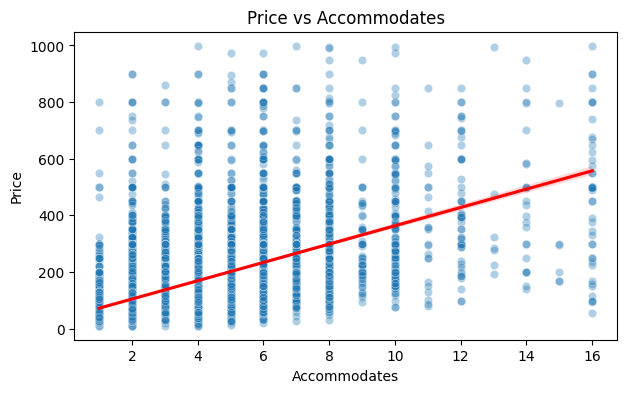

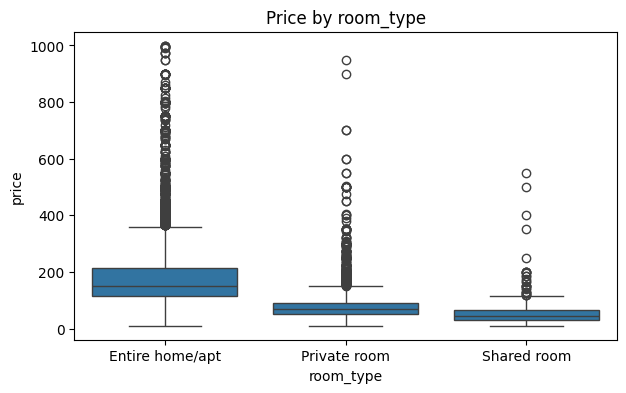

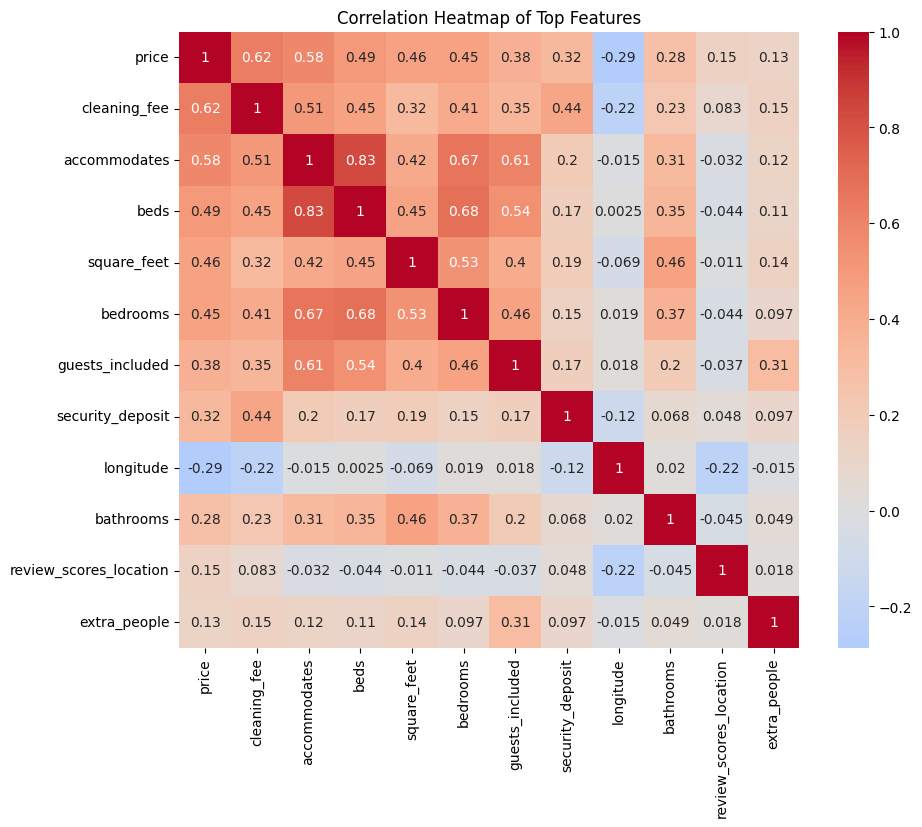

In [8]:
# EDA

plt.figure(figsize=(7,4))
sns.histplot(train_df["price"], bins=60, kde=True)
plt.title("Price distribution")
plt.show()

if "accommodates" in train_df.columns:
    plt.figure(figsize=(7,4))
    sns.scatterplot(data=train_df, x="accommodates", y="price", alpha=0.35)

    sns.regplot(
        data=train_df,
        x="accommodates",
        y="price",
        scatter=False,
        color="red"
    )

    plt.title("Price vs Accommodates")
    plt.xlabel("Accommodates")
    plt.ylabel("Price")

    plt.show()

if "room_type" in train_df.columns:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=train_df, x="room_type", y="price")
    plt.title("Price by room_type")
    plt.show()

# Correlation heatmap
numeric_cols = train_df.select_dtypes(include=["number"]).columns
corr_price = train_df[numeric_cols].corr()["price"].abs().sort_values(ascending=False)

# top 12 features most correlated with price
top_features = corr_price.index[:12]
plt.figure(figsize=(10,8))

sns.heatmap(
    train_df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Top Features")
plt.show()

### EDA Observations

### Price Distribution
- The price distribution is right-skewed, meaning most Airbnb listings are priced between 50–200 dollars, while a small number of listings have very high prices.
- The presence of extreme high-price values indicates outliers, suggesting that applying a log transformation (log1p) can help stabilize the target variable for modeling.


###  Price vs Accommodates
- There is a clear positive relationship between the number of guests a listing accommodates and its price; larger properties tend to charge higher nightly rates.
- However, the wide vertical spread at each accommodates level suggests that other factors like location, amenities, and property type also influence pricing.


###  Price by Room Type
- Listings categorized as Entire home/apt have significantly higher median prices compared to private or shared rooms.
- Shared rooms have the lowest prices**, indicating that room type is a strong categorical predictor of listing price.


###  Correlation Heatmap of Top Features
- Features such as cleaning fee, accommodates, beds, bedrooms, and square_feet show moderate positive correlation with price, indicating they are important predictors.
- Geographic features like longitude and review scores show weak correlation with price, suggesting their influence may be more complex or indirect.

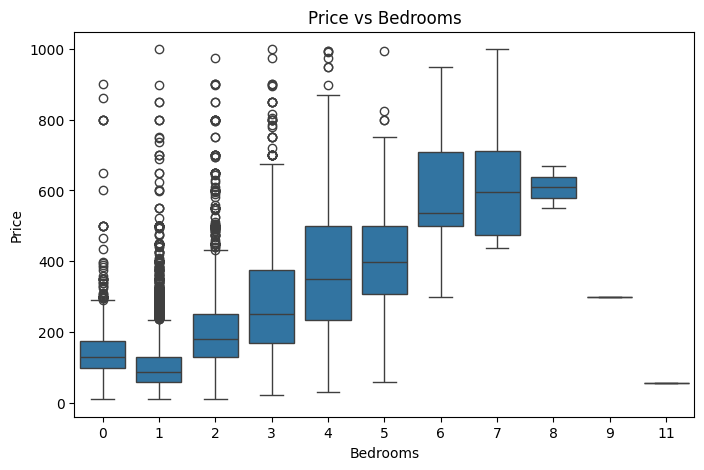

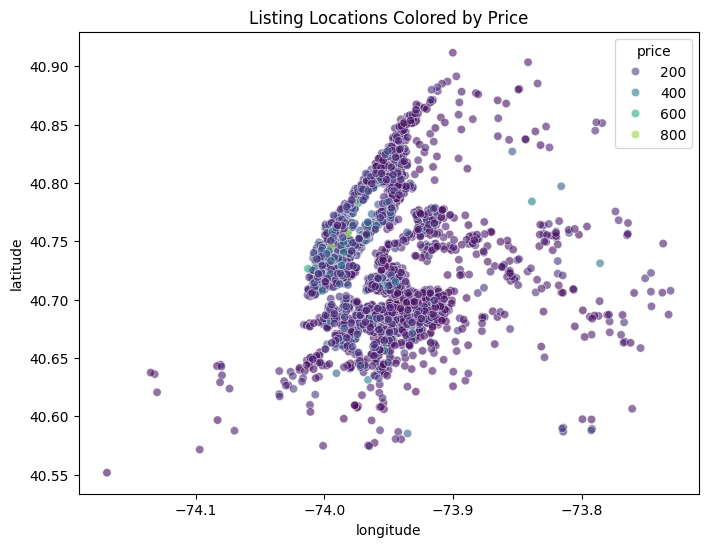

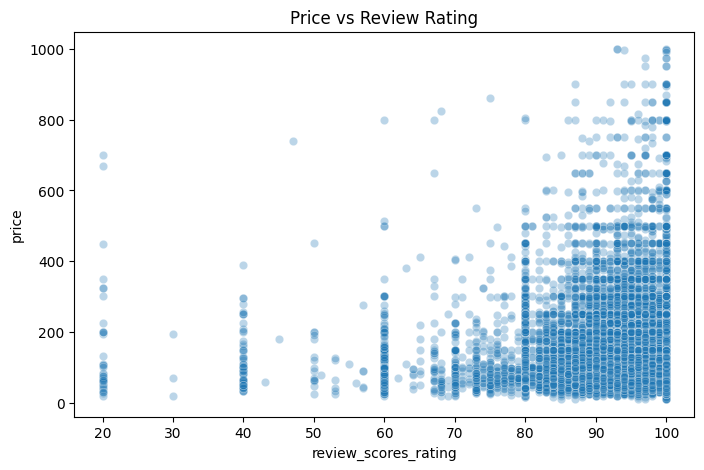

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train_df,
    x="bedrooms",
    y="price"
)

plt.title("Price vs Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

#

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=train_df.sample(3000),
    x="longitude",
    y="latitude",
    hue="price",
    palette="viridis",
    alpha=0.6
)

plt.title("Listing Locations Colored by Price")

plt.show()

#

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train_df,
    x="review_scores_rating",
    y="price",
    alpha=0.3
)

plt.title("Price vs Review Rating")

plt.show()

### EDA Observations

**Price vs Bedrooms**
- Listings with more bedrooms generally have higher prices.
- Price variability within each bedroom category suggests other factors (location, amenities) also influence pricing.

**Listing Locations Colored by Price**
- Listings are highly concentrated in central geographic areas.
- Higher priced listings tend to appear more frequently in prime locations.

**Price vs Review Rating**
- Most listings have high ratings above 80.
- Review rating does not show a strong direct relationship with price.

In [10]:
# ===== Feature builder =====

def one_hot_from_train(train_s: pd.Series, test_s: pd.Series, prefix: str):
    train_s = train_s.fillna("NaN").astype(str)
    categories = pd.Index(train_s.unique())
    train_cat = pd.Categorical(train_s, categories=categories)

    test_s = test_s.fillna("NaN").astype(str)
    test_cat = pd.Categorical(test_s, categories=categories)

    train_oh = pd.get_dummies(train_cat, prefix=prefix)
    test_oh = pd.get_dummies(test_cat, prefix=prefix)
    test_oh = test_oh.reindex(columns=train_oh.columns, fill_value=0)

    return (
        train_oh.astype(np.float32).to_numpy(),
        test_oh.astype(np.float32).to_numpy(),
        list(train_oh.columns),
    )


def many_hot_from_train(train_lists: list[list[str]], test_lists: list[list[str]], prefix: str):
    vocab = sorted({t for row in train_lists for t in row})
    idx = {t: i for i, t in enumerate(vocab)}

    def build(lists: list[list[str]]):
        X = np.zeros((len(lists), len(vocab)), dtype=np.float32)
        for r, row in enumerate(lists):
            for t in row:
                i = idx.get(t)
                if i is not None:
                    X[r, i] = 1.0
        return X

    X_tr = build(train_lists)
    X_te = build(test_lists)
    names = [f"{prefix}__{t}" for t in vocab]
    return X_tr, X_te, names


def build_features(train_df: pd.DataFrame, test_df: pd.DataFrame):
    feats_tr = []
    feats_te = []
    feat_names = []

    # Numeric + missing indicators
    for col in NUMERIC_COLS:
        if col not in train_df.columns or col not in test_df.columns:
            continue
        tr = pd.to_numeric(train_df[col], errors="coerce")
        te = pd.to_numeric(test_df[col], errors="coerce")

        tr_missing = tr.isna().astype(np.float32).to_numpy().reshape(-1, 1)
        te_missing = te.isna().astype(np.float32).to_numpy().reshape(-1, 1)

        tr = tr.fillna(0.0).astype(np.float32).to_numpy().reshape(-1, 1)
        te = te.fillna(0.0).astype(np.float32).to_numpy().reshape(-1, 1)

        feats_tr.extend([tr, tr_missing])
        feats_te.extend([te, te_missing])
        feat_names.extend([col, f"{col}__missing"])

    # String-numeric / money + missing indicators
    for col in STRING_NUMERIC_COLS:
        if col not in train_df.columns or col not in test_df.columns:
            continue
        tr_raw = train_df[col].apply(parse_money_to_float)
        te_raw = test_df[col].apply(parse_money_to_float)

        tr_missing = tr_raw.isna().astype(np.float32).to_numpy().reshape(-1, 1)
        te_missing = te_raw.isna().astype(np.float32).to_numpy().reshape(-1, 1)

        tr = tr_raw.fillna(0.0).astype(np.float32).to_numpy().reshape(-1, 1)
        te = te_raw.fillna(0.0).astype(np.float32).to_numpy().reshape(-1, 1)

        feats_tr.extend([tr, tr_missing])
        feats_te.extend([te, te_missing])
        feat_names.extend([col, f"{col}__missing"])

    # Booleans + missing indicators
    for col in BOOL_COLS:
        if col not in train_df.columns or col not in test_df.columns:
            continue
        tr_raw = train_df[col].apply(to_bool01)
        te_raw = test_df[col].apply(to_bool01)

        tr_missing = tr_raw.isna().astype(np.float32).to_numpy().reshape(-1, 1)
        te_missing = te_raw.isna().astype(np.float32).to_numpy().reshape(-1, 1)

        tr = tr_raw.fillna(0.0).astype(np.float32).to_numpy().reshape(-1, 1)
        te = te_raw.fillna(0.0).astype(np.float32).to_numpy().reshape(-1, 1)

        feats_tr.extend([tr, tr_missing])
        feats_te.extend([te, te_missing])
        feat_names.extend([col, f"{col}__missing"])

    # Categorical (one-hot, train categories only)
    for col in CAT_COLS:
        if col not in train_df.columns or col not in test_df.columns:
            continue
        tr_oh, te_oh, names = one_hot_from_train(train_df[col], test_df[col], prefix=col)
        feats_tr.append(tr_oh)
        feats_te.append(te_oh)
        feat_names.extend(names)

    # Set-valued many-hot + count
    if SET_COL in train_df.columns and SET_COL in test_df.columns:
        tr_lists = train_df[SET_COL].apply(parse_listlike).tolist()
        te_lists = test_df[SET_COL].apply(parse_listlike).tolist()

        tr_mh, te_mh, names = many_hot_from_train(tr_lists, te_lists, prefix=SET_COL)
        feats_tr.append(tr_mh)
        feats_te.append(te_mh)
        feat_names.extend(names)

        feats_tr.append(np.array([len(x) for x in tr_lists], dtype=np.float32).reshape(-1, 1))
        feats_te.append(np.array([len(x) for x in te_lists], dtype=np.float32).reshape(-1, 1))
        feat_names.append(f"{SET_COL}__count")

    # Location: lat/long + polynomial
    if all(c in train_df.columns and c in test_df.columns for c in LOC_COLS):
        tr_lat = pd.to_numeric(train_df["latitude"], errors="coerce").fillna(0.0).astype(np.float32).to_numpy()
        tr_lon = pd.to_numeric(train_df["longitude"], errors="coerce").fillna(0.0).astype(np.float32).to_numpy()
        te_lat = pd.to_numeric(test_df["latitude"], errors="coerce").fillna(0.0).astype(np.float32).to_numpy()
        te_lon = pd.to_numeric(test_df["longitude"], errors="coerce").fillna(0.0).astype(np.float32).to_numpy()

        tr_loc = np.vstack([tr_lat, tr_lon, tr_lat**2, tr_lon**2, tr_lat * tr_lon]).T
        te_loc = np.vstack([te_lat, te_lon, te_lat**2, te_lon**2, te_lat * te_lon]).T

        feats_tr.append(tr_loc)
        feats_te.append(te_loc)
        feat_names.extend(["latitude", "longitude", "latitude2", "longitude2", "lat_lon"])

    # Zipcode: frequency encoding (better than one-hot for high-cardinality)
    if ZIP_COL in train_df.columns and ZIP_COL in test_df.columns:
        tr_f, te_f = freq_encode_from_train(train_df[ZIP_COL], test_df[ZIP_COL])
        feats_tr.append(tr_f.astype(np.float32))
        feats_te.append(te_f.astype(np.float32))
        feat_names.append(f"{ZIP_COL}__freq")

    # Optional text embeddings
    if EMBEDDING_MODE != "none" and EMB_PATH.exists():
        emb = pd.read_csv(EMB_PATH)
        if "id" not in emb.columns:
            raise ValueError("Embeddings file must include an 'id' column")

        tr_m = train_df[["id"]].merge(emb, on="id", how="left")
        te_m = test_df[["id"]].merge(emb, on="id", how="left")

        emb_cols = [c for c in tr_m.columns if c != "id"]
        tr_e = tr_m[emb_cols].fillna(0.0).to_numpy(dtype=np.float32)
        te_e = te_m[emb_cols].fillna(0.0).to_numpy(dtype=np.float32)

        if EMBEDDING_MODE == "sample":
            rng = np.random.default_rng(SEED)
            k = min(EMBEDDING_SAMPLE_K, tr_e.shape[1])
            idx = rng.choice(tr_e.shape[1], size=k, replace=False)
            feats_tr.append(tr_e[:, idx])
            feats_te.append(te_e[:, idx])
            feat_names.extend([f"emb_{i}" for i in idx])

        elif EMBEDDING_MODE == "svd":
            from sklearn.decomposition import TruncatedSVD
            k = min(EMBEDDING_SVD_K, tr_e.shape[1] - 1)
            svd = TruncatedSVD(n_components=k, random_state=SEED)
            feats_tr.append(svd.fit_transform(tr_e).astype(np.float32))
            feats_te.append(svd.transform(te_e).astype(np.float32))
            feat_names.extend([f"emb_svd_{i}" for i in range(k)])
        else:
            raise ValueError("Unknown EMBEDDING_MODE")

    X_tr = np.hstack(feats_tr) if feats_tr else np.zeros((len(train_df), 0), dtype=np.float32)
    X_te = np.hstack(feats_te) if feats_te else np.zeros((len(test_df), 0), dtype=np.float32)
    return X_tr, X_te, feat_names


train_X_df = train_df.drop(columns=[c for c in PRICE_COLUMNS if c in train_df.columns], errors="ignore")
test_X_df  = test_df.drop(columns=[c for c in PRICE_COLUMNS if c in test_df.columns], errors="ignore")

X, X_test, feature_names = build_features(train_X_df, test_X_df)

print("X shape     ", X.shape)
print("X_test shape", X_test.shape)
print("#features   ", len(feature_names))

X shape      (23291, 159)
X_test shape (5828, 159)
#features    159


In [11]:
# ===== Train/valid split =====

y = train_df["price"].astype(float).to_numpy()

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(train_df))
n_valid = int(round(VALID_FRAC * len(train_df)))
valid_idx = perm[:n_valid]
train_idx = perm[n_valid:]

X_tr = X[train_idx]
y_tr = y[train_idx]
X_va = X[valid_idx]
y_va = y[valid_idx]

mean, std = standardize_fit(X_tr)
X_tr_s = standardize_apply(X_tr, mean, std)
X_va_s = standardize_apply(X_va, mean, std)
X_test_s = standardize_apply(X_test, mean, std)

w = fit_ridge(X_tr_s, y_tr, alpha=RIDGE_ALPHA)
va_pred = predict_ridge(X_va_s, w)

print("Validation RMSLE:", rmsle(y_va, va_pred))

Validation RMSLE: 0.6236970531485342


In [12]:
# Model Experiment

# Ridge
mean, std = standardize_fit(X_tr)
X_tr_s = standardize_apply(X_tr, mean, std)
X_va_s = standardize_apply(X_va, mean, std)

w = fit_ridge(X_tr_s, y_tr, RIDGE_ALPHA)
va_pred_ridge = np.maximum(0, predict_ridge(X_va_s, w))
ridge_score = rmsle(y_va, va_pred_ridge)
print("Ridge RMSLE:", ridge_score)


# Shared log targets
y_tr_log = np.log1p(y_tr)
y_va_log = np.log1p(y_va)


# XGBoost (log target)
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=SEED,
    n_jobs=-1
)

xgb.fit(X_tr, y_tr_log)
va_pred_xgb = np.maximum(0, np.expm1(xgb.predict(X_va)))
xgb_score = rmsle(y_va, va_pred_xgb)
print("XGBoost RMSLE:", xgb_score)


# LightGBM (lighter + safer early stopping)
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=4000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=8,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    force_row_wise=True,
    verbosity=-1,
    random_state=SEED,
    n_jobs=4
)

lgbm.fit(
    X_tr, y_tr_log,
    eval_set=[(X_va, y_va_log)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(100)
    ]
)

va_pred_lgb = np.maximum(
    0, np.expm1(lgbm.predict(X_va, num_iteration=lgbm.best_iteration_))
)
lgb_score = rmsle(y_va, va_pred_lgb)
print("LightGBM best_iteration:", lgbm.best_iteration_)
print("LightGBM RMSLE:", lgb_score)


# HistGBM (sklearn) (log target)
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    max_iter=2000,
    learning_rate=0.03,
    max_depth=8,
    l2_regularization=0.1,
    random_state=SEED
)

hgb.fit(X_tr, y_tr_log)
va_pred_hgb = np.maximum(0, np.expm1(hgb.predict(X_va)))
hgb_score = rmsle(y_va, va_pred_hgb)
print("HistGBM RMSLE:", hgb_score)


results = pd.DataFrame({
    "Model": ["Ridge", "XGBoost", "LightGBM", "HistGBM"],
    "RMSLE": [ridge_score, xgb_score, lgb_score, hgb_score]
}).sort_values("RMSLE")

results

Ridge RMSLE: 0.6236970531485342
XGBoost RMSLE: 0.29401536873807854
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.312679	valid_0's l2: 0.0977681
[200]	valid_0's rmse: 0.299088	valid_0's l2: 0.0894537
[300]	valid_0's rmse: 0.295488	valid_0's l2: 0.0873134
[400]	valid_0's rmse: 0.29399	valid_0's l2: 0.08643
[500]	valid_0's rmse: 0.29286	valid_0's l2: 0.0857669
[600]	valid_0's rmse: 0.292675	valid_0's l2: 0.0856584
[700]	valid_0's rmse: 0.292425	valid_0's l2: 0.0855126
[800]	valid_0's rmse: 0.292211	valid_0's l2: 0.0853875
[900]	valid_0's rmse: 0.292083	valid_0's l2: 0.0853125
Early stopping, best iteration is:
[864]	valid_0's rmse: 0.292026	valid_0's l2: 0.0852794


/Users/nithinprince/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM best_iteration: 864
LightGBM RMSLE: 0.29202643581022536
HistGBM RMSLE: 0.29732007324028725


,Model,RMSLE
2,LightGBM,0.292026
1,XGBoost,0.294015
3,HistGBM,0.297320
0,Ridge,0.623697


In [13]:
# # Model Experiment

# # Ridge
# mean, std = standardize_fit(X_tr)
# X_tr_s = standardize_apply(X_tr, mean, std)
# X_va_s = standardize_apply(X_va, mean, std)

# w = fit_ridge(X_tr_s, y_tr, RIDGE_ALPHA)
# va_pred_ridge = np.maximum(0, predict_ridge(X_va_s, w))
# ridge_score = rmsle(y_va, va_pred_ridge)
# print("Ridge RMSLE:", ridge_score)


# # XGBoost (log target)
# from xgboost import XGBRegressor

# xgb = XGBRegressor(
#     n_estimators=4000,
#     learning_rate=0.03,
#     max_depth=8,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     reg_alpha=0.1,
#     reg_lambda=1.5,
#     random_state=SEED,
#     n_jobs=-1
# )
# xgb.fit(X_tr, np.log1p(y_tr))
# va_pred_xgb = np.maximum(0, np.expm1(xgb.predict(X_va)))
# xgb_score = rmsle(y_va, va_pred_xgb)
# print("XGBoost RMSLE:", xgb_score)


# # LightGBM (log target + early stopping)
# import lightgbm as lgb

# lgbm = lgb.LGBMRegressor(
#     n_estimators=50000,
#     learning_rate=0.01,
#     num_leaves=512,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.2,
#     reg_lambda=2.0,
#     random_state=SEED,
#     n_jobs=-1
# )

# lgbm.fit(
#     X_tr, np.log1p(y_tr),
#     eval_set=[(X_va, np.log1p(y_va))],
#     eval_metric="rmse",
#     callbacks=[lgb.early_stopping(stopping_rounds=300, verbose=False)]
# )

# va_pred_lgb = np.maximum(0, np.expm1(lgbm.predict(X_va, num_iteration=lgbm.best_iteration_)))
# lgb_score = rmsle(y_va, va_pred_lgb)
# print("LightGBM RMSLE:", lgb_score)


# # HistGBM (sklearn) (log target)
# from sklearn.ensemble import HistGradientBoostingRegressor

# hgb = HistGradientBoostingRegressor(
#     max_iter=2000,
#     learning_rate=0.03,
#     max_depth=8,
#     l2_regularization=0.1,
#     random_state=SEED
# )
# hgb.fit(X_tr, np.log1p(y_tr))
# va_pred_hgb = np.maximum(0, np.expm1(hgb.predict(X_va)))
# hgb_score = rmsle(y_va, va_pred_hgb)
# print("HistGBM RMSLE:", hgb_score)


# results = pd.DataFrame({
#     "Model": ["Ridge", "XGBoost", "LightGBM", "HistGBM"],
#     "RMSLE": [ridge_score, xgb_score, lgb_score, hgb_score]
# }).sort_values("RMSLE")

# results

In [14]:
# Ablations

def score_lightgbm_with_X(X_in):
    X_tr2 = X_in[train_idx]
    X_va2 = X_in[valid_idx]

    m = lgb.LGBMRegressor(
        n_estimators=50000,
        learning_rate=0.01,
        num_leaves=512,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=2.0,
        random_state=SEED,
        n_jobs=-1
    )
    m.fit(
        X_tr2, np.log1p(y_tr),
        eval_set=[(X_va2, np.log1p(y_va))],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=300, verbose=False)]
    )
    pred = np.maximum(0, np.expm1(m.predict(X_va2, num_iteration=m.best_iteration_)))
    return rmsle(y_va, pred)

# Location OFF
_loc_backup = LOC_COLS
try:
    LOC_COLS = []  # disable location
    X_noloc, Xtest_noloc, _ = build_features(train_X_df, test_X_df)
finally:
    LOC_COLS = _loc_backup

score_noloc = score_lightgbm_with_X(X_noloc)

# Embeddings ON
_emb_backup = EMBEDDING_MODE
score_emb = np.nan
try:
    if EMB_PATH.exists():
        EMBEDDING_MODE = "svd"
        X_emb, Xtest_emb, _ = build_features(train_X_df, test_X_df)
        score_emb = score_lightgbm_with_X(X_emb)
finally:
    EMBEDDING_MODE = _emb_backup

abl = pd.DataFrame({
    "Experiment": ["LightGBM full", "LightGBM NO location", "LightGBM + embeddings(SVD)"],
    "RMSLE": [lgb_score, score_noloc, score_emb]
}).sort_values("RMSLE")

abl

/Users/nithinprince/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Experiment,RMSLE
0,LightGBM full,0.292026
1,LightGBM NO location,0.296703
2,LightGBM + embeddings(SVD),NaN


,Model,RMSLE
0,LightGBM Model,0.292026
1,XGBoost Model,0.294015
2,HistGradientBoosting Model,0.297320
3,Ridge Baseline,0.623697


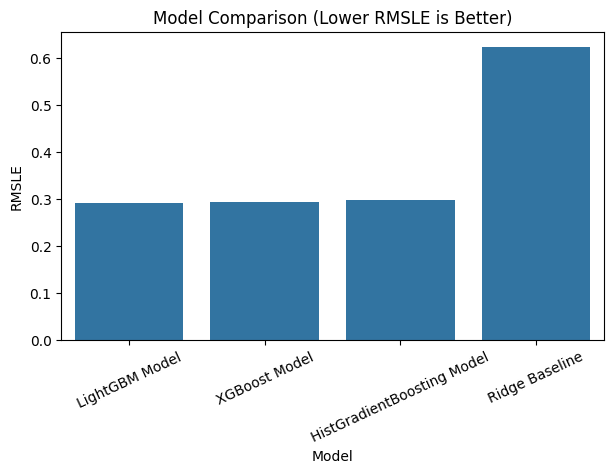

In [15]:
experiment_results = pd.DataFrame({
    "Model": [
        "Ridge Baseline",
        "XGBoost Model",
        "LightGBM Model",
        "HistGradientBoosting Model"
    ],
    "RMSLE": [
        ridge_score,
        xgb_score,
        lgb_score,
        hgb_score
    ]
})

experiment_results = experiment_results.sort_values("RMSLE").reset_index(drop=True)

display(experiment_results)

plt.figure(figsize=(7,4))

sns.barplot(
    data=experiment_results,
    x="Model",
    y="RMSLE"
)

plt.title("Model Comparison (Lower RMSLE is Better)")
plt.xticks(rotation=25)
plt.show()

In [16]:
# Train LightGBM on FULL train set
y = train_df["price"].astype(float).to_numpy()

final_lgbm = lgb.LGBMRegressor(
    n_estimators=6000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=SEED,
    n_jobs=-1
)

final_lgbm.fit(X, np.log1p(y))

test_pred = np.expm1(final_lgbm.predict(X_test))
test_pred = np.maximum(0, test_pred)

submission = pd.DataFrame({
    "id": test_df["id"],
    "price": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

/Users/nithinprince/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,id,price
0,6853271,212.803700
1,4149022,115.887195
2,22972810,50.318652
3,13980911,61.879884
4,21999726,41.962457


In [17]:
# Train XGBoost on FULL train set

y = train_df["price"].astype(float).to_numpy()

final_xgb = XGBRegressor(
     n_estimators=6000,
     learning_rate=0.03,
     max_depth=8,
     subsample=0.85,
     colsample_bytree=0.85,
     reg_alpha=0.1,
     reg_lambda=1.5,
     random_state=SEED,
     n_jobs=-1
 )

final_xgb.fit(X, np.log1p(y))

test_pred = np.expm1(final_xgb.predict(X_test))
test_pred = np.maximum(0, test_pred)

submission = pd.DataFrame({"id": test_df["id"], "price": test_pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,price
0,6853271,187.411133
1,4149022,130.601929
2,22972810,54.686737
3,13980911,61.137474
4,21999726,48.968292


In [18]:
# Validate submission file format, column names, numeric predictions, and row count against test data
sub = pd.read_csv("submission.csv")
print(sub.shape)
print(sub.columns.tolist())
print("missing ids:", sub["id"].isna().sum())
print("non-numeric price:", pd.to_numeric(sub["price"], errors="coerce").isna().sum())
print("matches test rows:", len(sub) == len(test_df))

(5828, 2)
['id', 'price']
missing ids: 0
non-numeric price: 0
matches test rows: True


# NOTE: The target variable y is not modified.
# Models train on log1p(y_tr) but evaluation always uses rmsle(y_va, predictions).

In [22]:
import pickle
from pathlib import Path

Path("models").mkdir(exist_ok=True)

with open("models/model.pkl", "wb") as f:
    pickle.dump(final_lgbm, f)

print("Model saved!")


Model saved!


In [23]:
import pickle
from pathlib import Path

Path("models").mkdir(exist_ok=True)

with open("models/model.pkl", "wb") as f:
    pickle.dump(final_lgbm, f)

with open("models/train_reference.pkl", "wb") as f:
    pickle.dump(train_X_df, f)

with open("models/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print("Saved model, train reference, and feature names.")

Saved model, train reference, and feature names.
